<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Magnetic_Flux_Density_of_a_2_Pole_Halbach_PMG_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [3]:
!uv pip install --system -q numpy scipy matplotlib

Two-pole linear Halbach PMG analytical field model
PMG width                       : 150.000 mm
Pole pitch N-to-S               : 75.000 mm
Magnetic wavelength             : 150.000 mm
Fundamental wavenumber          : 41.887902 rad/m
Magnet thickness                : 12.000 mm
Observation gap                 : 15.000 mm
Specified remanence Br           : 1.2000 T
Specified coercivity Hc          : 883,310.0 A/m
Relative permeability            : 1.04500
mu0 * mu_r * Hc diagnostic       : 1.1600 T
Segmentation factor              : 0.900316
Fundamental surface amplitude    : 0.4268 T
Fundamental amplitude at gap     : 0.2277 T
----------------------------------------------------------------------------
Signed integral of By            : 0.0000 T*mm
Unsigned integral of |By|        : 21.7448 T*mm
Signed integral of Bx            : 0.0000 T*mm
Unsigned integral of |Bx|        : 21.7448 T*mm
Peak |Bx|                        : 0.227711 T
Peak |By|                        : 0.227711 T
Peak |

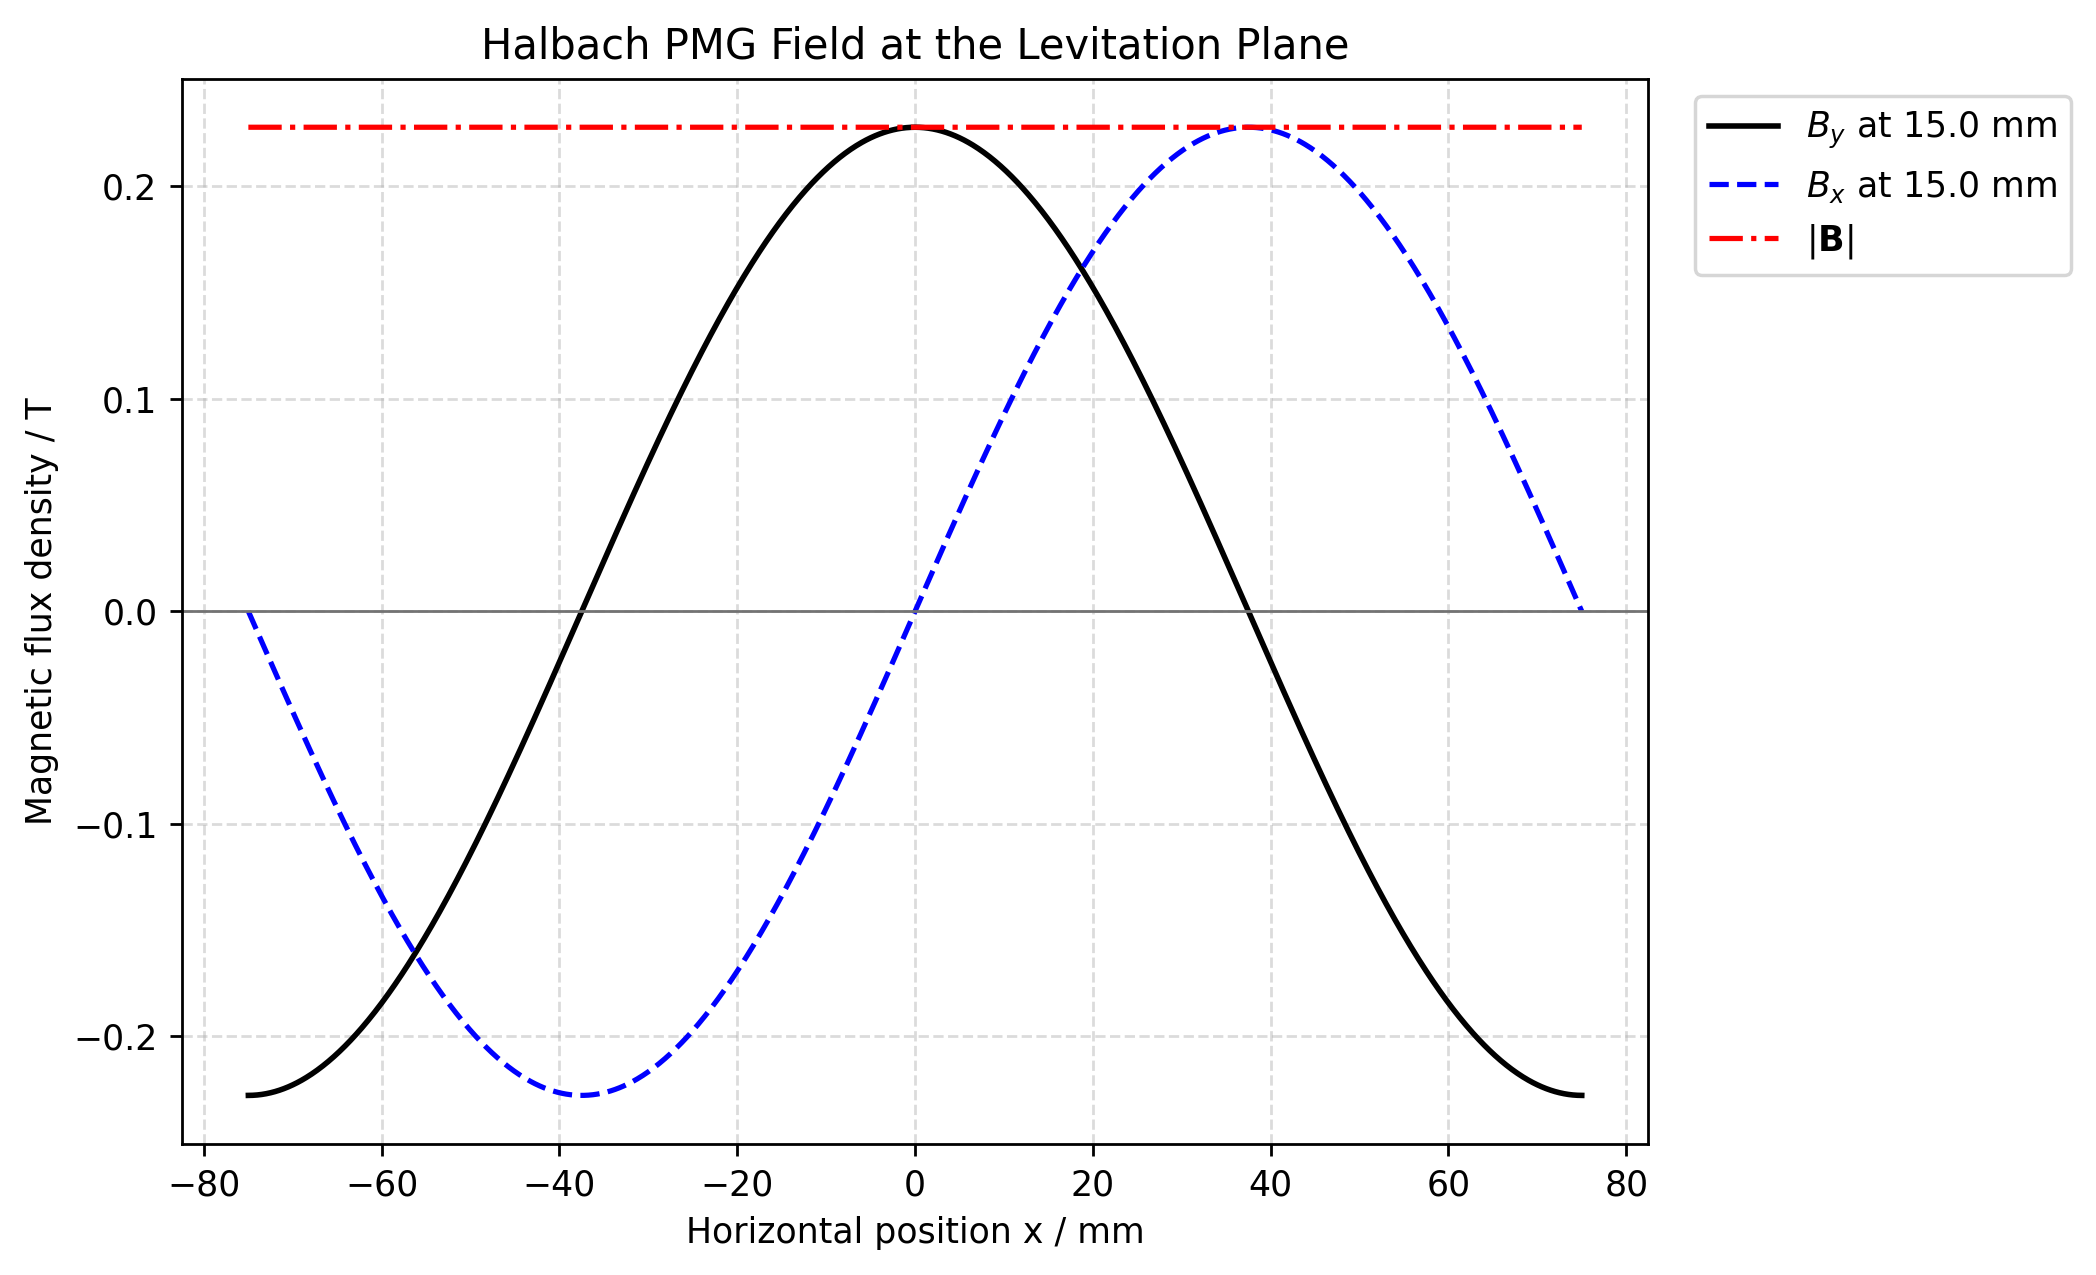

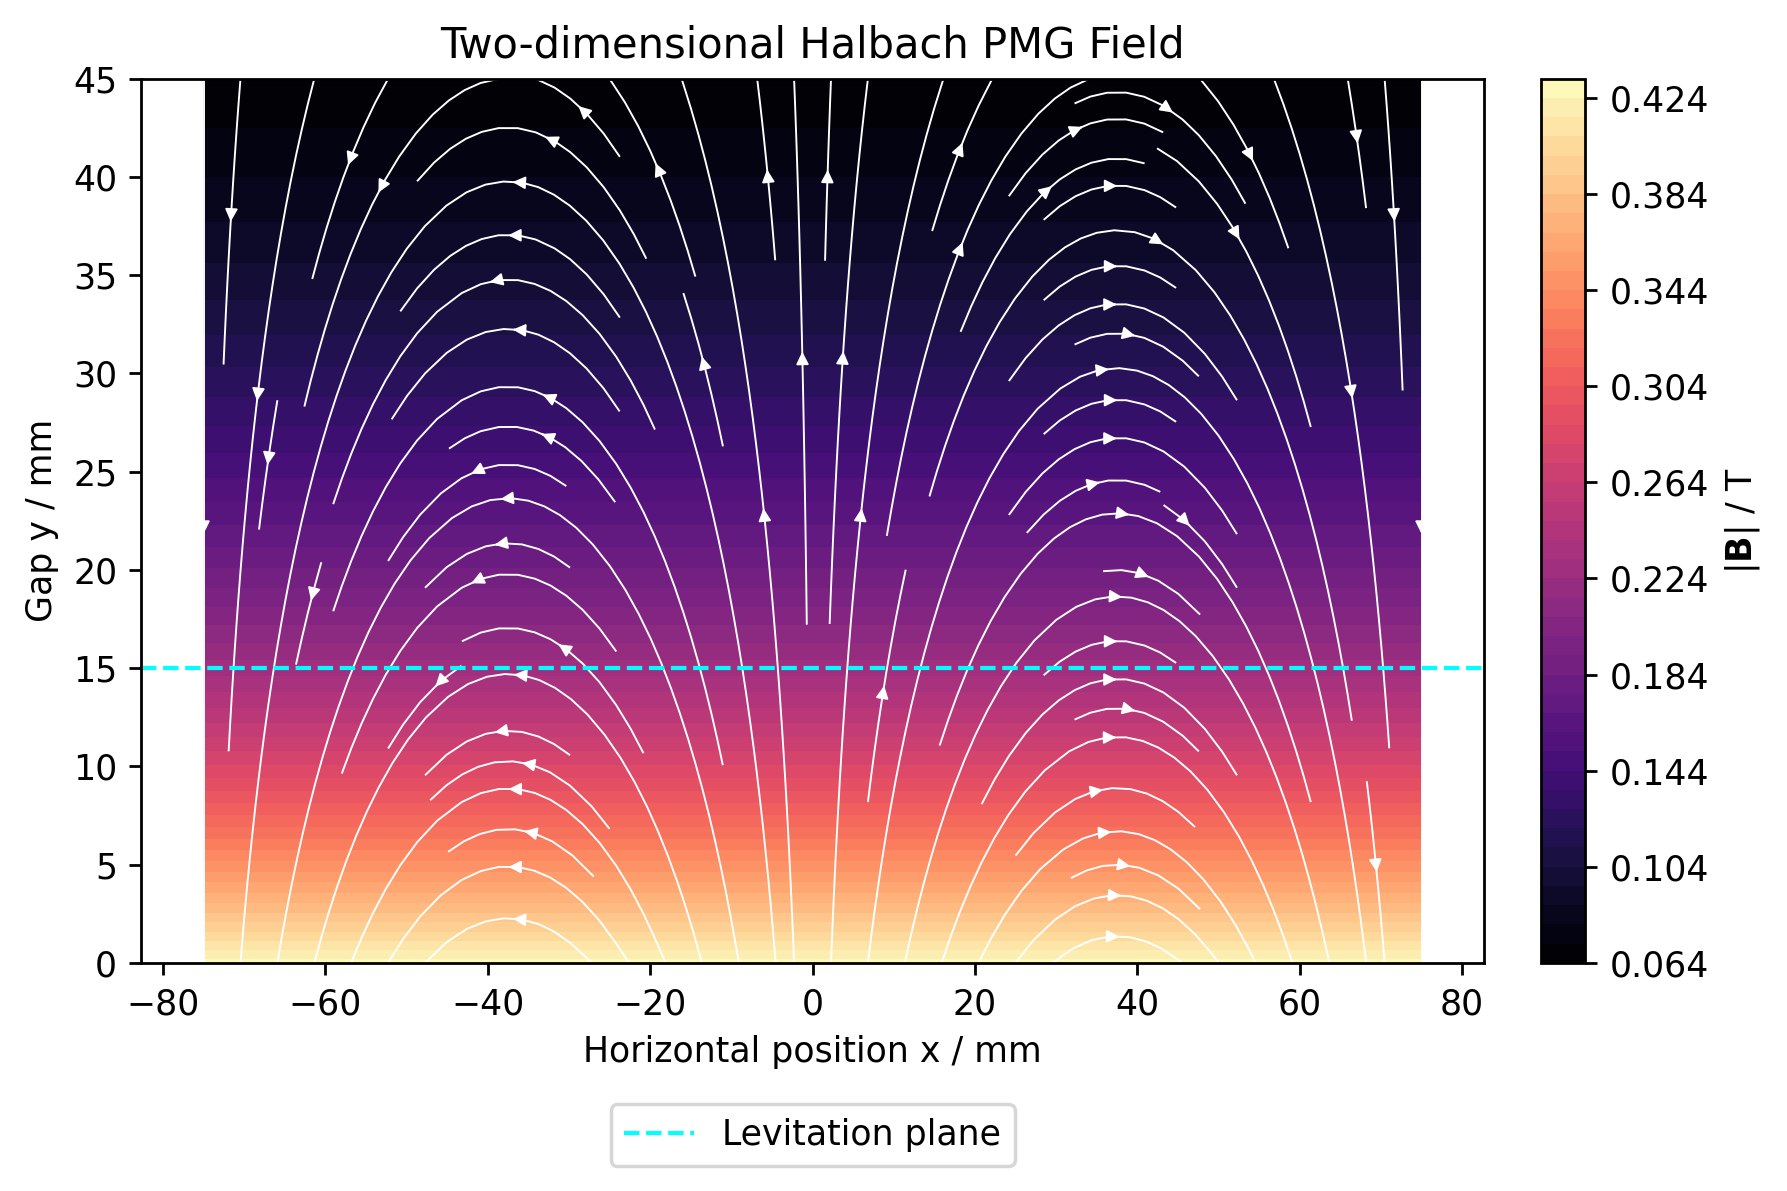

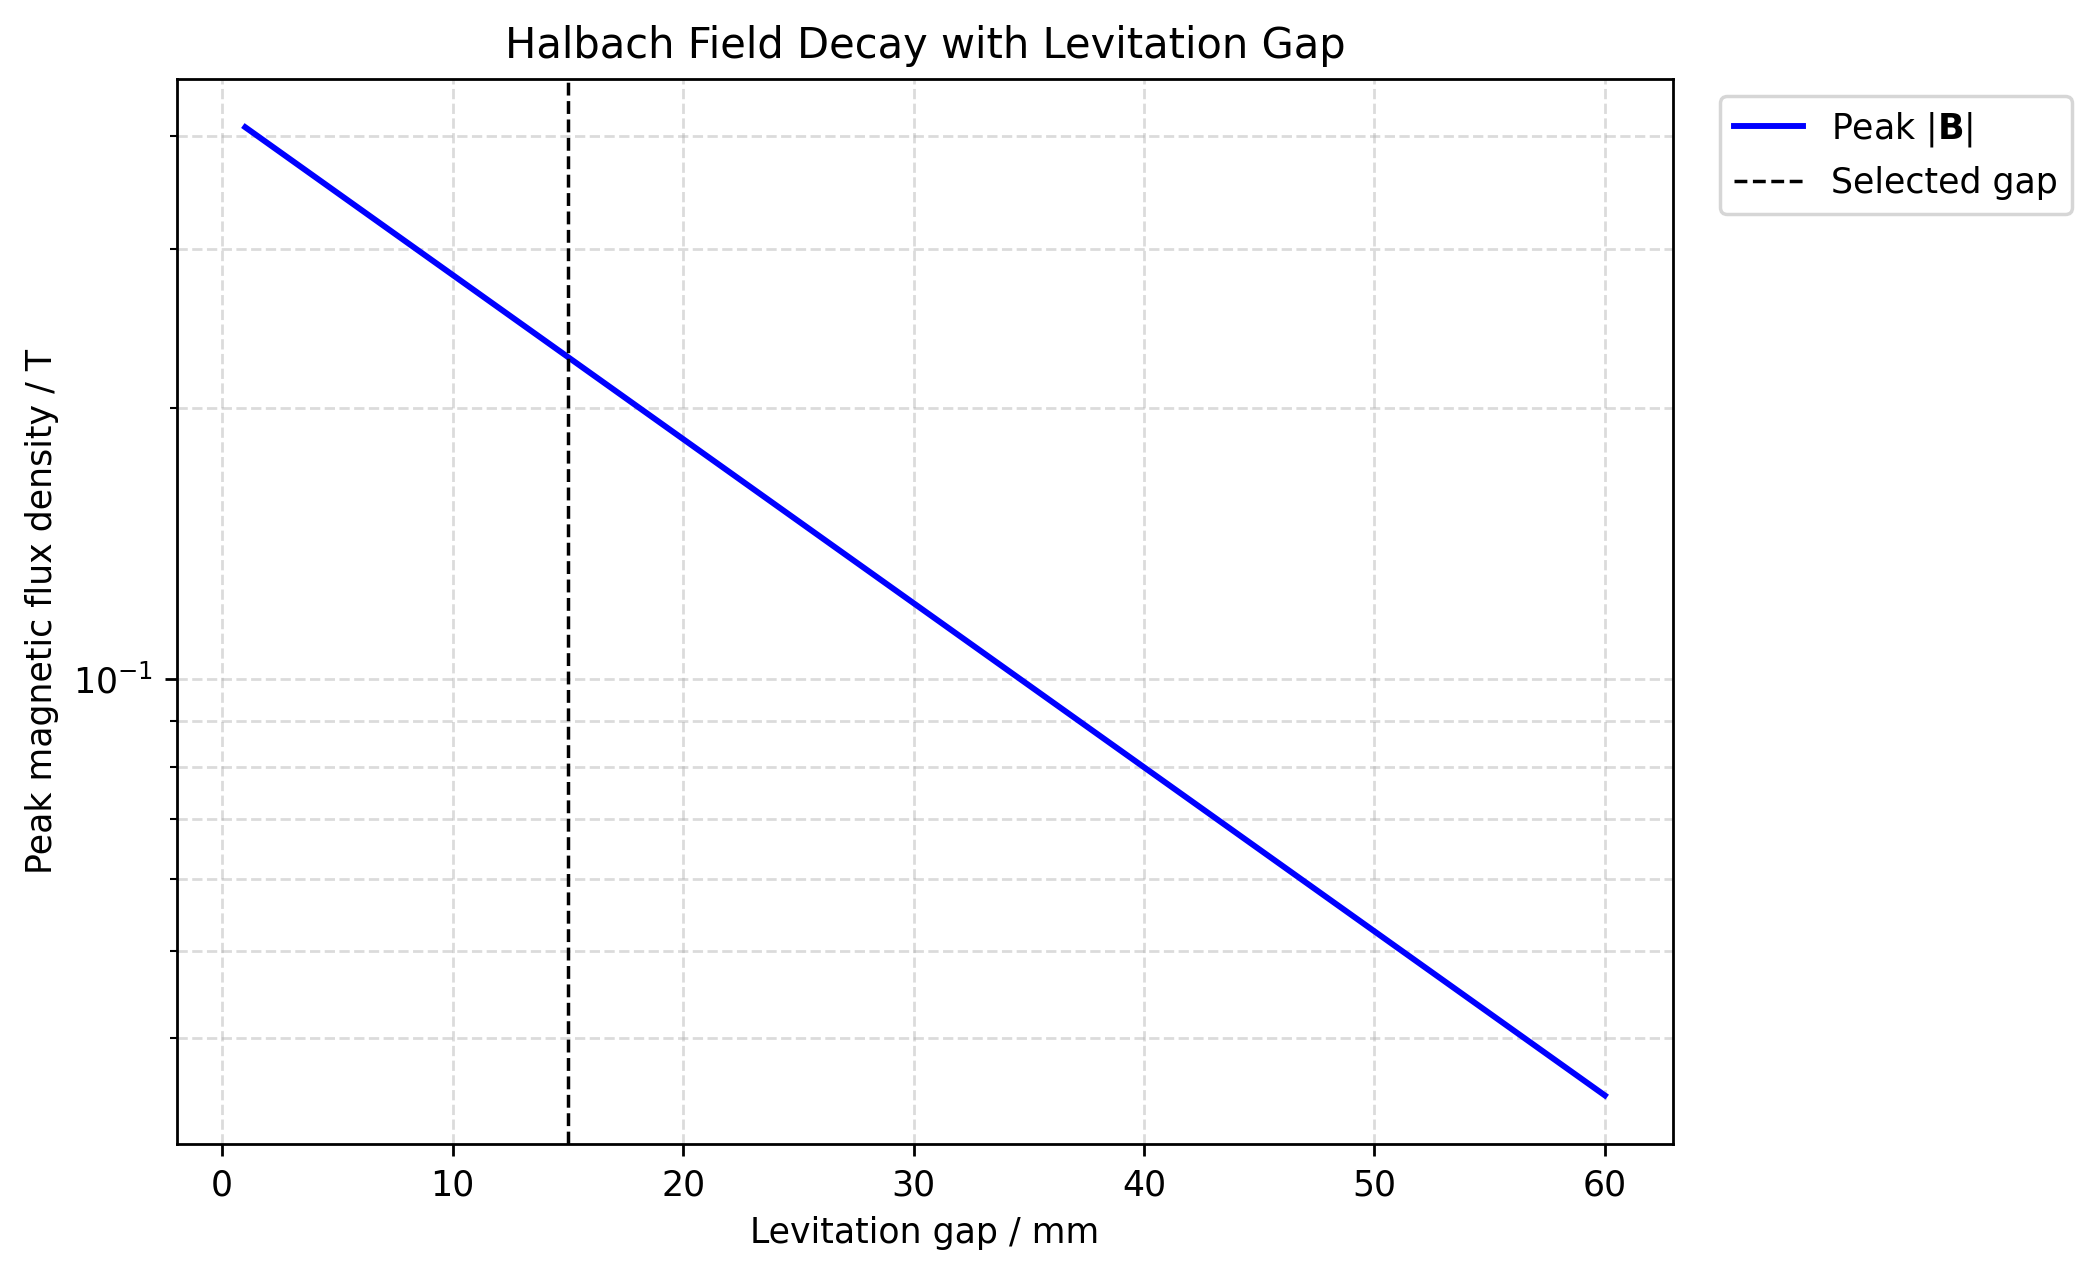

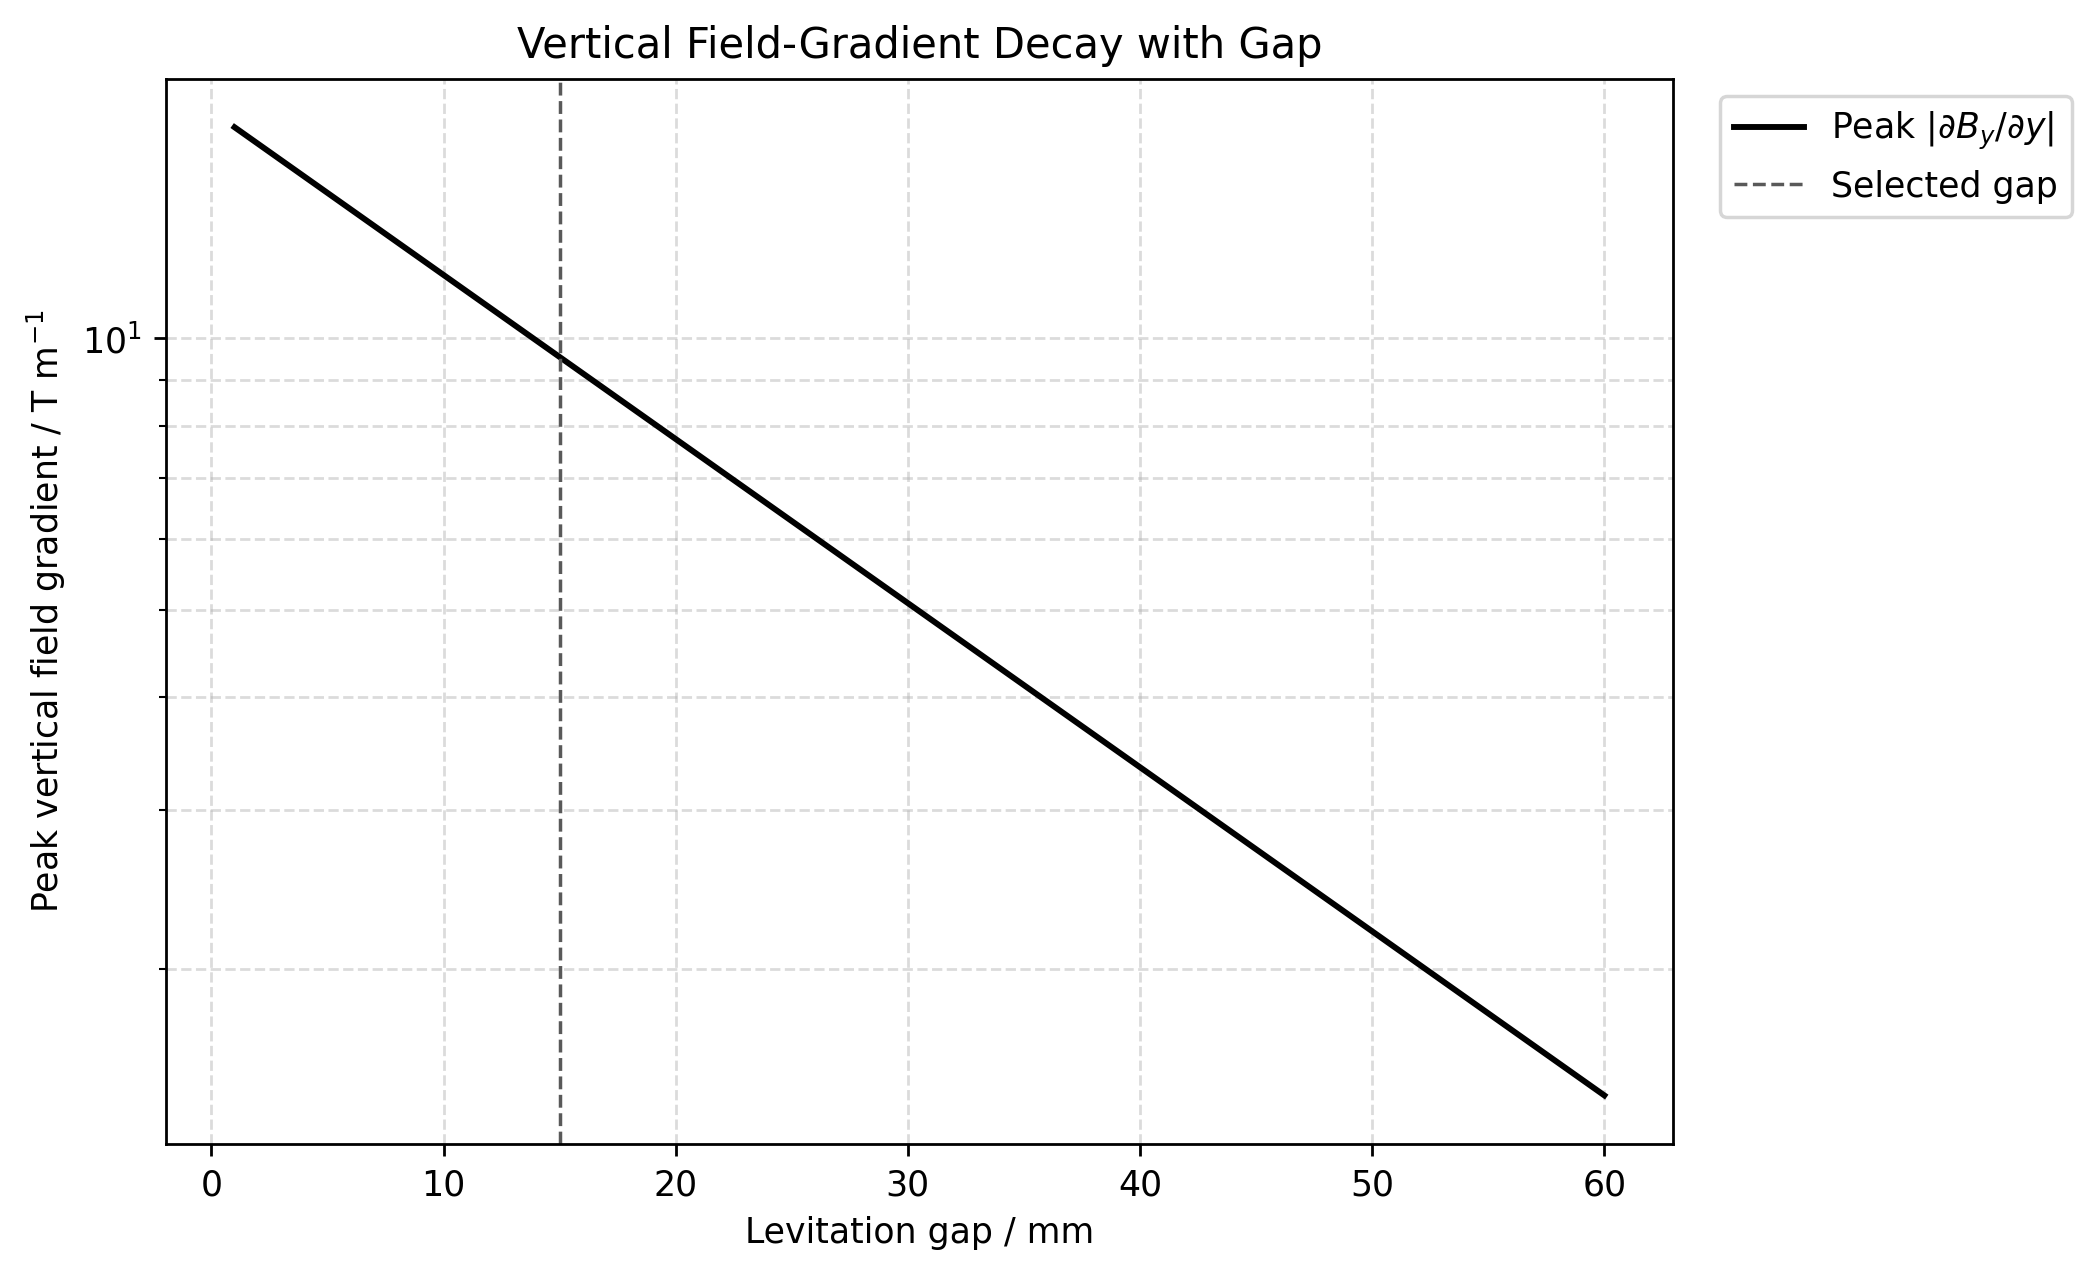

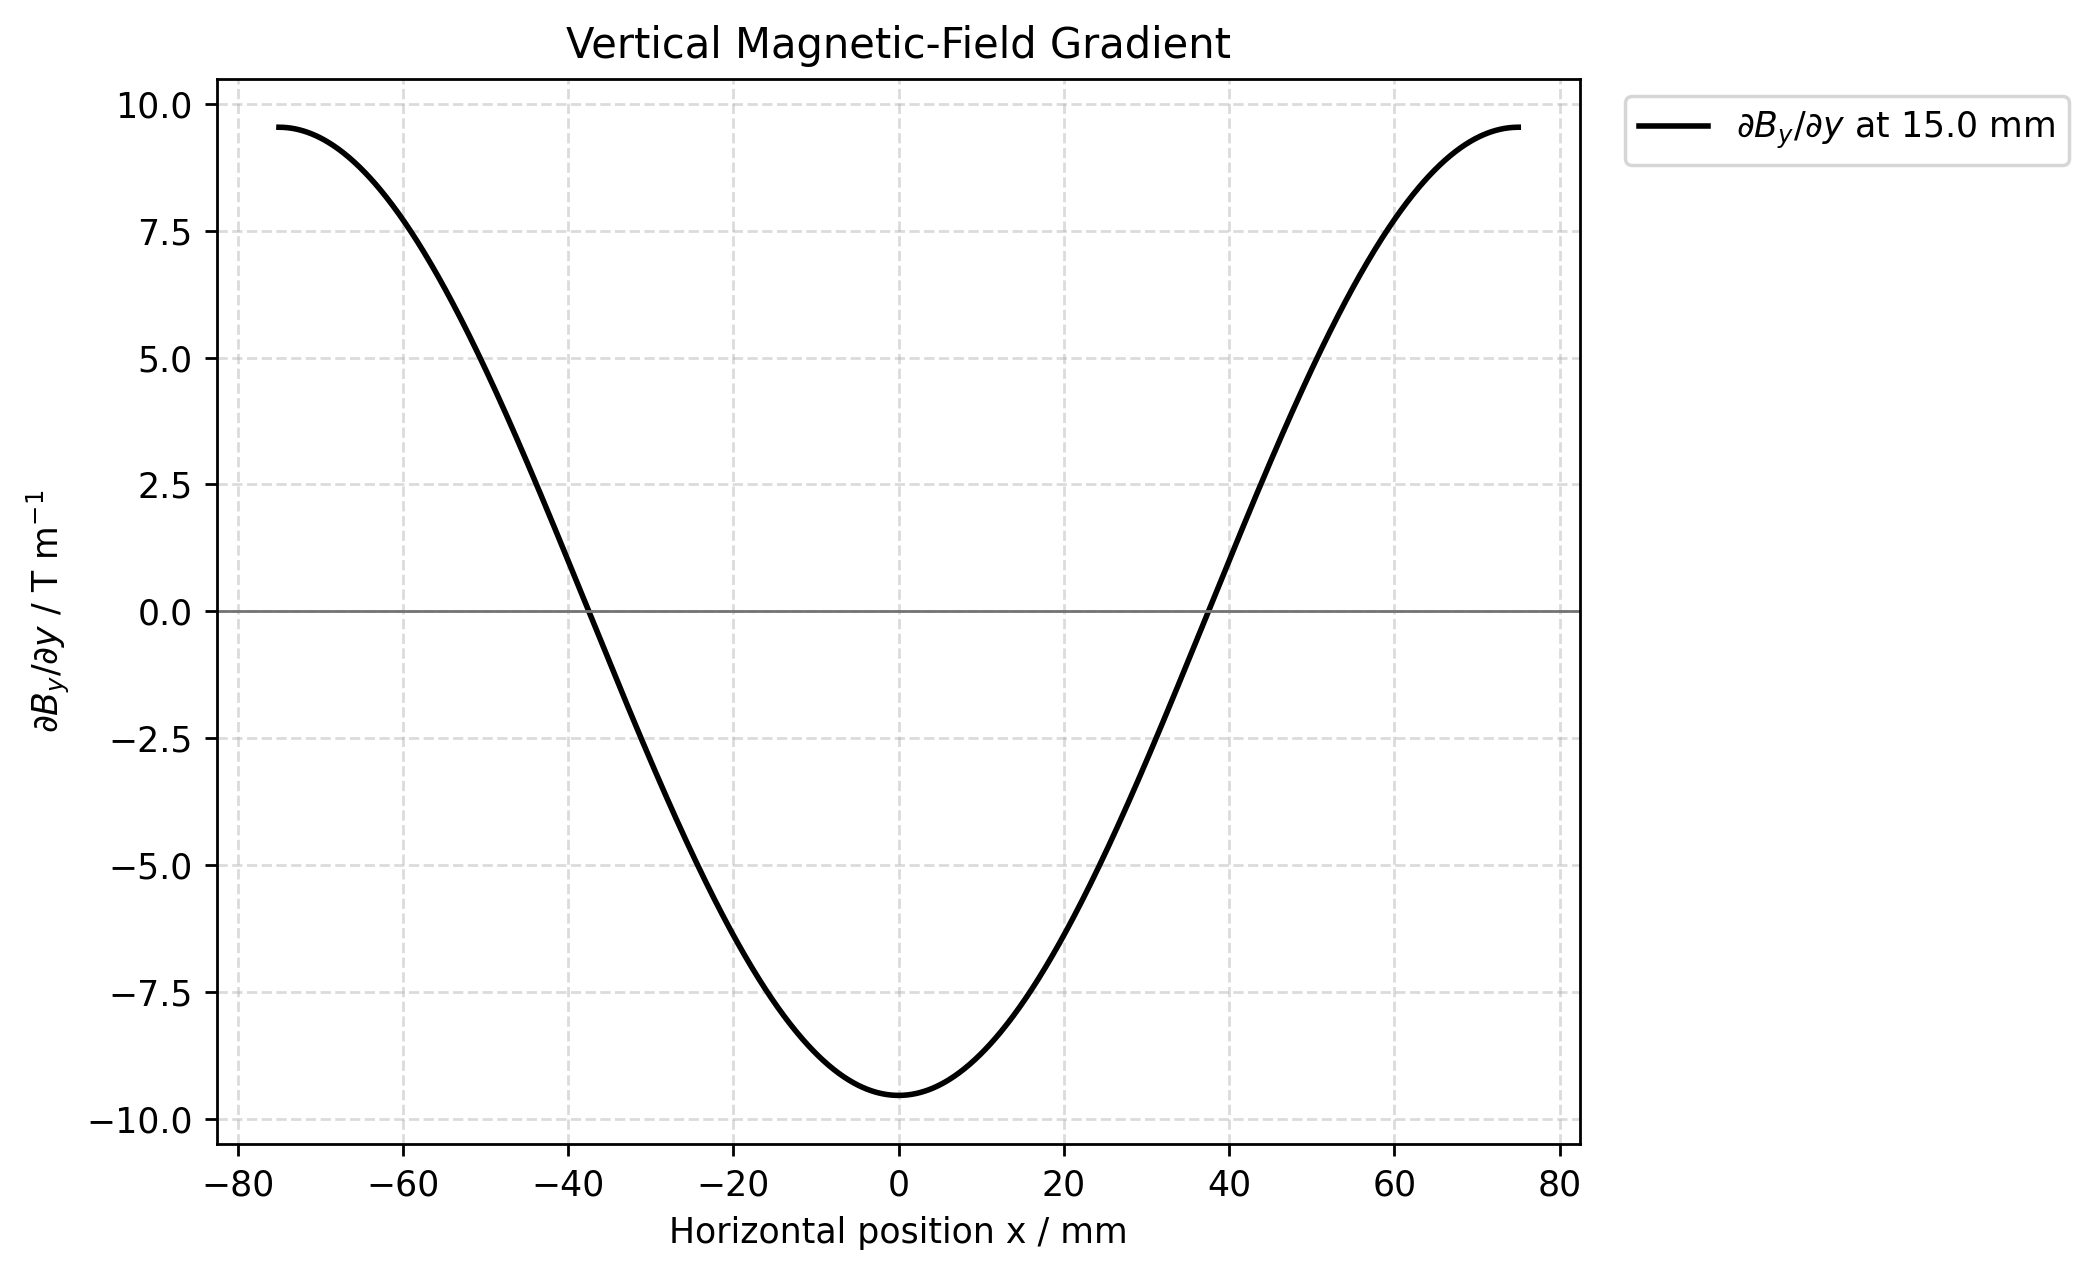

In [6]:
"""Analytical field model for a two-pole linear Halbach permanent-magnet guideway.

The model treats the Halbach array as an infinitely wide, spatially periodic,
two-dimensional magnetization distribution. The default configuration uses one
magnetic wavelength across the modeled PMG width. Optional user-defined spatial
harmonics can approximate departures from an ideal sinusoidal magnetization.

The calculation is performed in SI units internally and plotted in millimetres.

Important model boundaries:
    * End effects and finite lateral width are omitted.
    * Iron back-yokes, conducting reaction plates, eddy currents, saturation,
      temperature dependence, and nonlinear magnetic materials are omitted.
    * Remanence B_r is supplied directly. Coercivity H_c is retained only as a
      material diagnostic and is not used to infer B_r.
    * The finite-magnet-thickness factor is an analytical approximation for a
      linear Halbach sheet.
"""

from dataclasses import dataclass
from typing import Mapping

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import simpson


# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------

# Geometry
PMG_WIDTH_MM = 150.0
POLE_PITCH_MM = 75.0
MAGNET_THICKNESS_MM = 12.0
LEVITATION_GAP_MM = 15.0

# Permanent-magnet material
B_REMANENCE_T = 1.20
COERCIVITY_A_PER_M = 883_310.0
RELATIVE_PERMEABILITY = 1.045

# Halbach discretization
APPLY_SEGMENTATION_CORRECTION = True
MAGNETIZATION_SEGMENTS_PER_WAVELENGTH = 4

# Spatial harmonic content. Values are amplitude ratios relative to the
# fundamental surface-field scale. Keep {1: 1.0} for the ideal fundamental.
HARMONIC_AMPLITUDE_RATIOS = {
    1: 1.0,
    3: 0.0,
    5: 0.0,
}

# Field phase at x = 0
PHASE_DEG = 0.0

# Sampling
X_SAMPLES = 1201
Y_SAMPLES = 241
FIELD_MAP_MAX_GAP_MM = 45.0

# Gap sweep
GAP_SWEEP_MIN_MM = 1.0
GAP_SWEEP_MAX_MM = 60.0
GAP_SWEEP_SAMPLES = 300

# Visualization
FIGURE_DPI = 250
FIGURE_SIZE = (8.5, 5.2)
STREAMLINE_DENSITY = 1.15
SHOW_FIELD_PROFILE = True
SHOW_FIELD_MAP = True
SHOW_GAP_SWEEP = True
SHOW_GRADIENT_PROFILE = True

# Numerical checks
RUN_MAXWELL_SANITY_CHECK = True
MAXWELL_CHECK_X_SAMPLES = 401
MAXWELL_CHECK_Y_SAMPLES = 161
RESIDUAL_RELATIVE_TOLERANCE = 5.0e-2


# -----------------------------------------------------------------------------
# Matplotlib configuration
# -----------------------------------------------------------------------------

matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans"]
matplotlib.rcParams["font.weight"] = "normal"
matplotlib.rcParams["figure.dpi"] = FIGURE_DPI
matplotlib.rcParams["savefig.dpi"] = FIGURE_DPI


MU_0 = 4.0 * np.pi * 1.0e-7


@dataclass(frozen=True)
class HalbachConfig:
    """Physical and numerical parameters for the analytical Halbach model."""

    pmg_width_m: float
    pole_pitch_m: float
    magnet_thickness_m: float
    levitation_gap_m: float
    b_remanence_t: float
    coercivity_a_per_m: float
    relative_permeability: float
    segmentation_enabled: bool
    segments_per_wavelength: int
    harmonic_amplitude_ratios: Mapping[int, float]
    phase_rad: float

    @property
    def magnetic_wavelength_m(self) -> float:
        """Return one magnetic wavelength, containing one pole pair."""
        return 2.0 * self.pole_pitch_m

    @property
    def fundamental_wavenumber_per_m(self) -> float:
        """Return the fundamental spatial wavenumber in rad/m."""
        return 2.0 * np.pi / self.magnetic_wavelength_m


@dataclass(frozen=True)
class FieldMetrics:
    """Summary metrics for a one-dimensional field profile."""

    signed_vertical_flux_t_m: float
    unsigned_vertical_flux_t_m: float
    signed_horizontal_flux_t_m: float
    unsigned_horizontal_flux_t_m: float
    peak_bx_t: float
    peak_by_t: float
    peak_b_total_t: float
    mean_b_total_t: float
    rms_bx_t: float
    rms_by_t: float
    rms_b_total_t: float
    peak_abs_dby_dy_t_per_m: float


def mm_to_m(value_mm: float | np.ndarray) -> float | np.ndarray:
    """Convert millimetres to metres."""
    return np.asarray(value_mm) * 1.0e-3


def m_to_mm(value_m: float | np.ndarray) -> float | np.ndarray:
    """Convert metres to millimetres."""
    return np.asarray(value_m) * 1.0e3


def validate_config(config: HalbachConfig) -> None:
    """Validate physical and numerical model parameters.

    Args:
        config: Halbach model configuration.

    Raises:
        ValueError: If any parameter is physically or numerically invalid.
    """
    positive_values = {
        "PMG width": config.pmg_width_m,
        "pole pitch": config.pole_pitch_m,
        "magnet thickness": config.magnet_thickness_m,
        "remanence": config.b_remanence_t,
        "relative permeability": config.relative_permeability,
    }
    for name, value in positive_values.items():
        if value <= 0.0:
            raise ValueError(f"{name} must be greater than zero.")

    if config.levitation_gap_m < 0.0:
        raise ValueError("Levitation gap must be zero or greater.")

    if config.segments_per_wavelength < 2:
        raise ValueError("At least two magnetization segments are required.")

    if not config.harmonic_amplitude_ratios:
        raise ValueError("At least one harmonic must be supplied.")

    for order, amplitude in config.harmonic_amplitude_ratios.items():
        if not isinstance(order, int) or order < 1:
            raise ValueError("Harmonic orders must be positive integers.")
        if not np.isfinite(amplitude):
            raise ValueError("Harmonic amplitudes must be finite.")

    expected_width = config.magnetic_wavelength_m
    if not np.isclose(config.pmg_width_m, expected_width, rtol=0.0, atol=1e-12):
        print(
            "Note: PMG width differs from one magnetic wavelength. "
            "This is allowed, but the plotted domain will contain "
            f"{config.pmg_width_m / expected_width:.3f} wavelengths."
        )


def segmentation_fundamental_factor(segments_per_wavelength: int) -> float:
    """Return the approximate fundamental loss from piecewise magnetization.

    The factor sin(pi/N)/(pi/N) approximates the reduction of the fundamental
    Fourier component when an ideal rotating magnetization is represented by N
    uniform angular segments per magnetic wavelength.

    Args:
        segments_per_wavelength: Number of discrete magnetization directions.

    Returns:
        Dimensionless fundamental-amplitude correction.
    """
    return float(np.sinc(1.0 / segments_per_wavelength))


def thickness_factor(wavenumber_per_m: float, thickness_m: float) -> float:
    """Return the finite-thickness field factor 1 - exp(-k t)."""
    return float(-np.expm1(-wavenumber_per_m * thickness_m))


def harmonic_surface_amplitude(
    config: HalbachConfig,
    harmonic_order: int,
    relative_amplitude: float,
) -> float:
    """Calculate the surface amplitude for one spatial harmonic.

    Args:
        config: Halbach model configuration.
        harmonic_order: Positive spatial-harmonic order.
        relative_amplitude: Amplitude relative to the fundamental scale.

    Returns:
        Surface field amplitude in tesla before air-gap decay.
    """
    k_n = harmonic_order * config.fundamental_wavenumber_per_m
    finite_thickness = thickness_factor(k_n, config.magnet_thickness_m)

    segmentation = 1.0
    if config.segmentation_enabled and harmonic_order == 1:
        segmentation = segmentation_fundamental_factor(
            config.segments_per_wavelength
        )

    return (
        config.b_remanence_t
        * finite_thickness
        * segmentation
        * relative_amplitude
    )


def calculate_magnetic_field(
    x_m: np.ndarray,
    y_m: np.ndarray | float,
    config: HalbachConfig,
) -> tuple[np.ndarray, np.ndarray]:
    """Calculate Bx and By for the configured spatial-harmonic model.

    The analytical form for each harmonic is

        Bx_n = Bn exp(-k_n y) sin(k_n x + n phi)
        By_n = Bn exp(-k_n y) cos(k_n x + n phi)

    which is divergence-free and curl-free in the source-free air region for
    each individual harmonic.

    Args:
        x_m: Horizontal coordinate array in metres.
        y_m: Vertical coordinate or array in metres.
        config: Halbach model configuration.

    Returns:
        Tuple containing Bx and By arrays in tesla.
    """
    x_array, y_array = np.broadcast_arrays(
        np.asarray(x_m, dtype=float),
        np.asarray(y_m, dtype=float),
    )

    if np.any(y_array < 0.0):
        raise ValueError("Observation height y must be zero or greater.")

    b_x = np.zeros_like(x_array, dtype=float)
    b_y = np.zeros_like(x_array, dtype=float)

    for order, relative_amplitude in sorted(
        config.harmonic_amplitude_ratios.items()
    ):
        if relative_amplitude == 0.0:
            continue

        k_n = order * config.fundamental_wavenumber_per_m
        surface_amplitude = harmonic_surface_amplitude(
            config,
            harmonic_order=order,
            relative_amplitude=relative_amplitude,
        )
        decay = np.exp(-k_n * y_array)
        phase = k_n * x_array + order * config.phase_rad

        b_x += surface_amplitude * decay * np.sin(phase)
        b_y += surface_amplitude * decay * np.cos(phase)

    return b_x, b_y


def calculate_vertical_gradient(
    x_m: np.ndarray,
    y_m: np.ndarray | float,
    config: HalbachConfig,
) -> np.ndarray:
    """Calculate the analytical vertical derivative dBy/dy in T/m."""
    x_array, y_array = np.broadcast_arrays(
        np.asarray(x_m, dtype=float),
        np.asarray(y_m, dtype=float),
    )
    gradient = np.zeros_like(x_array, dtype=float)

    for order, relative_amplitude in sorted(
        config.harmonic_amplitude_ratios.items()
    ):
        if relative_amplitude == 0.0:
            continue

        k_n = order * config.fundamental_wavenumber_per_m
        surface_amplitude = harmonic_surface_amplitude(
            config,
            harmonic_order=order,
            relative_amplitude=relative_amplitude,
        )
        decay = np.exp(-k_n * y_array)
        phase = k_n * x_array + order * config.phase_rad

        gradient -= (
            k_n
            * surface_amplitude
            * decay
            * np.cos(phase)
        )

    return gradient


def calculate_metrics(
    x_m: np.ndarray,
    b_x: np.ndarray,
    b_y: np.ndarray,
    dby_dy_t_per_m: np.ndarray,
) -> FieldMetrics:
    """Calculate integrated, RMS, peak, and gradient metrics."""
    b_total = np.hypot(b_x, b_y)

    return FieldMetrics(
        signed_vertical_flux_t_m=float(simpson(b_y, x=x_m)),
        unsigned_vertical_flux_t_m=float(simpson(np.abs(b_y), x=x_m)),
        signed_horizontal_flux_t_m=float(simpson(b_x, x=x_m)),
        unsigned_horizontal_flux_t_m=float(simpson(np.abs(b_x), x=x_m)),
        peak_bx_t=float(np.max(np.abs(b_x))),
        peak_by_t=float(np.max(np.abs(b_y))),
        peak_b_total_t=float(np.max(b_total)),
        mean_b_total_t=float(np.mean(b_total)),
        rms_bx_t=float(np.sqrt(np.mean(b_x**2))),
        rms_by_t=float(np.sqrt(np.mean(b_y**2))),
        rms_b_total_t=float(np.sqrt(np.mean(b_total**2))),
        peak_abs_dby_dy_t_per_m=float(np.max(np.abs(dby_dy_t_per_m))),
    )


def calculate_gap_sweep(
    gaps_m: np.ndarray,
    config: HalbachConfig,
) -> tuple[np.ndarray, np.ndarray]:
    """Calculate peak field magnitude and peak |dBy/dy| versus gap."""
    x_m = np.linspace(
        -0.5 * config.magnetic_wavelength_m,
        0.5 * config.magnetic_wavelength_m,
        1201,
    )

    peak_field = np.empty_like(gaps_m, dtype=float)
    peak_gradient = np.empty_like(gaps_m, dtype=float)

    for index, gap_m in enumerate(gaps_m):
        b_x, b_y = calculate_magnetic_field(x_m, gap_m, config)
        gradient = calculate_vertical_gradient(x_m, gap_m, config)
        peak_field[index] = np.max(np.hypot(b_x, b_y))
        peak_gradient[index] = np.max(np.abs(gradient))

    return peak_field, peak_gradient


def maxwell_sanity_check(config: HalbachConfig) -> tuple[float, float]:
    """Estimate source-free Maxwell residuals using finite differences.

    Returns:
        Maximum normalized divergence and curl residuals. Values near zero
        indicate consistency with div(B)=0 and curl(B)=0 in the air region.
    """
    x_m = np.linspace(
        -0.5 * config.magnetic_wavelength_m,
        0.5 * config.magnetic_wavelength_m,
        MAXWELL_CHECK_X_SAMPLES,
    )
    y_start = max(1.0e-5, 0.05 * config.levitation_gap_m)
    y_end = max(
        config.levitation_gap_m,
        y_start + 0.5 * config.magnetic_wavelength_m,
    )
    y_m = np.linspace(y_start, y_end, MAXWELL_CHECK_Y_SAMPLES)

    x_grid, y_grid = np.meshgrid(x_m, y_m)
    b_x, b_y = calculate_magnetic_field(x_grid, y_grid, config)

    dx = float(x_m[1] - x_m[0])
    dy = float(y_m[1] - y_m[0])

    dbx_dx = np.gradient(b_x, dx, axis=1, edge_order=2)
    dbx_dy = np.gradient(b_x, dy, axis=0, edge_order=2)
    dby_dx = np.gradient(b_y, dx, axis=1, edge_order=2)
    dby_dy = np.gradient(b_y, dy, axis=0, edge_order=2)

    divergence = dbx_dx + dby_dy
    curl_z = dby_dx - dbx_dy

    field_scale = max(float(np.max(np.hypot(b_x, b_y))), 1.0e-15)
    length_scale = config.magnetic_wavelength_m
    derivative_scale = field_scale / length_scale

    normalized_divergence = float(
        np.max(np.abs(divergence)) / derivative_scale
    )
    normalized_curl = float(
        np.max(np.abs(curl_z)) / derivative_scale
    )

    return normalized_divergence, normalized_curl


def print_report(
    config: HalbachConfig,
    metrics: FieldMetrics,
) -> None:
    """Print model configuration, derived quantities, and field metrics."""
    k = config.fundamental_wavenumber_per_m
    segmentation = (
        segmentation_fundamental_factor(config.segments_per_wavelength)
        if config.segmentation_enabled
        else 1.0
    )
    fundamental_surface = harmonic_surface_amplitude(config, 1, 1.0)
    fundamental_gap = fundamental_surface * np.exp(
        -k * config.levitation_gap_m
    )

    # This value is shown only to illustrate why Br should not be inferred
    # directly from Hc.
    hc_based_induction = (
        MU_0
        * config.relative_permeability
        * config.coercivity_a_per_m
    )

    print("=" * 76)
    print("Two-pole linear Halbach PMG analytical field model")
    print("=" * 76)
    print(f"PMG width                       : {m_to_mm(config.pmg_width_m):.3f} mm")
    print(
        f"Pole pitch N-to-S               : "
        f"{m_to_mm(config.pole_pitch_m):.3f} mm"
    )
    print(
        f"Magnetic wavelength             : "
        f"{m_to_mm(config.magnetic_wavelength_m):.3f} mm"
    )
    print(f"Fundamental wavenumber          : {k:.6f} rad/m")
    print(
        f"Magnet thickness                : "
        f"{m_to_mm(config.magnet_thickness_m):.3f} mm"
    )
    print(
        f"Observation gap                 : "
        f"{m_to_mm(config.levitation_gap_m):.3f} mm"
    )
    print(f"Specified remanence Br           : {config.b_remanence_t:.4f} T")
    print(f"Specified coercivity Hc          : {config.coercivity_a_per_m:,.1f} A/m")
    print(f"Relative permeability            : {config.relative_permeability:.5f}")
    print(
        f"mu0 * mu_r * Hc diagnostic       : "
        f"{hc_based_induction:.4f} T"
    )
    print(
        f"Segmentation factor              : "
        f"{segmentation:.6f}"
    )
    print(
        f"Fundamental surface amplitude    : "
        f"{fundamental_surface:.4f} T"
    )
    print(
        f"Fundamental amplitude at gap     : "
        f"{fundamental_gap:.4f} T"
    )
    print("-" * 76)
    print(
        f"Signed integral of By            : "
        f"{metrics.signed_vertical_flux_t_m * 1e3:.4f} T*mm"
    )
    print(
        f"Unsigned integral of |By|        : "
        f"{metrics.unsigned_vertical_flux_t_m * 1e3:.4f} T*mm"
    )
    print(
        f"Signed integral of Bx            : "
        f"{metrics.signed_horizontal_flux_t_m * 1e3:.4f} T*mm"
    )
    print(
        f"Unsigned integral of |Bx|        : "
        f"{metrics.unsigned_horizontal_flux_t_m * 1e3:.4f} T*mm"
    )
    print(f"Peak |Bx|                        : {metrics.peak_bx_t:.6f} T")
    print(f"Peak |By|                        : {metrics.peak_by_t:.6f} T")
    print(f"Peak |B|                         : {metrics.peak_b_total_t:.6f} T")
    print(f"Mean |B|                         : {metrics.mean_b_total_t:.6f} T")
    print(f"RMS Bx                           : {metrics.rms_bx_t:.6f} T")
    print(f"RMS By                           : {metrics.rms_by_t:.6f} T")
    print(f"RMS |B|                          : {metrics.rms_b_total_t:.6f} T")
    print(
        f"Peak |dBy/dy|                    : "
        f"{metrics.peak_abs_dby_dy_t_per_m:.3f} T/m"
    )


def plot_field_profile(
    x_m: np.ndarray,
    b_x: np.ndarray,
    b_y: np.ndarray,
    config: HalbachConfig,
) -> None:
    """Plot signed field components and total field magnitude."""
    x_mm = m_to_mm(x_m)
    b_total = np.hypot(b_x, b_y)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.plot(
        x_mm,
        b_y,
        label=fr"$B_y$ at {m_to_mm(config.levitation_gap_m):.1f} mm",
        color="black",
        linewidth=1.6,
    )
    ax.plot(
        x_mm,
        b_x,
        label=fr"$B_x$ at {m_to_mm(config.levitation_gap_m):.1f} mm",
        color="#0000FF",
        linestyle="--",
        linewidth=1.5,
    )
    ax.plot(
        x_mm,
        b_total,
        label=r"$|\mathbf{B}|$",
        color="red",
        linestyle="-.",
        linewidth=1.5,
    )
    ax.axhline(0.0, color="0.45", linewidth=0.8)
    ax.set_xlabel("Horizontal position x / mm")
    ax.set_ylabel("Magnetic flux density / T")
    ax.set_title("Halbach PMG Field at the Levitation Plane")
    ax.grid(True, linestyle="--", alpha=0.45)
    ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
    fig.tight_layout()
    plt.show()


def plot_field_map(config: HalbachConfig) -> None:
    """Plot a two-dimensional field-magnitude map with flux streamlines."""
    x_m = np.linspace(
        -0.5 * config.pmg_width_m,
        0.5 * config.pmg_width_m,
        X_SAMPLES,
    )
    y_m = np.linspace(0.0, mm_to_m(FIELD_MAP_MAX_GAP_MM), Y_SAMPLES)
    x_grid, y_grid = np.meshgrid(x_m, y_m)

    b_x, b_y = calculate_magnetic_field(x_grid, y_grid, config)
    b_total = np.hypot(b_x, b_y)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    contour = ax.contourf(
        m_to_mm(x_grid),
        m_to_mm(y_grid),
        b_total,
        levels=50,
        cmap="magma",
    )
    ax.streamplot(
        m_to_mm(x_m),
        m_to_mm(y_m),
        b_x,
        b_y,
        density=STREAMLINE_DENSITY,
        color="white",
        linewidth=0.55,
        arrowsize=0.75,
    )
    ax.axhline(
        m_to_mm(config.levitation_gap_m),
        color="cyan",
        linestyle="--",
        linewidth=1.2,
        label="Levitation plane",
    )
    ax.set_xlabel("Horizontal position x / mm")
    ax.set_ylabel("Gap y / mm")
    ax.set_title("Two-dimensional Halbach PMG Field")

    # Keep the field-magnitude colorbar in its own right-side region.
    colorbar = fig.colorbar(contour, ax=ax, pad=0.035)
    colorbar.set_label(r"$|\mathbf{B}|$ / T")

    # Keep the legend outside the plotting area without competing for the
    # colorbar's right-side space. A bottom legend is robust to changes in
    # colorbar width, tick-label length, and figure aspect ratio.
    ax.legend(
        bbox_to_anchor=(0.5, -0.16),
        loc="upper center",
        borderaxespad=0.0,
        ncols=1,
    )

    # Reserve explicit space for the external legend. Avoid tight_layout()
    # here because it can move the axes back toward the colorbar and legend.
    fig.subplots_adjust(bottom=0.20, right=0.90)
    plt.show()


def plot_gap_sweep(config: HalbachConfig) -> None:
    """Plot peak field and vertical-gradient magnitude versus air gap."""
    gaps_mm = np.linspace(
        GAP_SWEEP_MIN_MM,
        GAP_SWEEP_MAX_MM,
        GAP_SWEEP_SAMPLES,
    )
    gaps_m = mm_to_m(gaps_mm)
    peak_field, peak_gradient = calculate_gap_sweep(gaps_m, config)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.semilogy(
        gaps_mm,
        peak_field,
        color="#0000FF",
        linewidth=1.7,
        label=r"Peak $|\mathbf{B}|$",
    )
    ax.axvline(
        m_to_mm(config.levitation_gap_m),
        color="black",
        linestyle="--",
        linewidth=1.0,
        label="Selected gap",
    )
    ax.set_xlabel("Levitation gap / mm")
    ax.set_ylabel("Peak magnetic flux density / T")
    ax.set_title("Halbach Field Decay with Levitation Gap")
    ax.grid(True, which="both", linestyle="--", alpha=0.45)
    ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.semilogy(
        gaps_mm,
        peak_gradient,
        color="black",
        linewidth=1.7,
        label=r"Peak $|\partial B_y/\partial y|$",
    )
    ax.axvline(
        m_to_mm(config.levitation_gap_m),
        color="0.35",
        linestyle="--",
        linewidth=1.0,
        label="Selected gap",
    )
    ax.set_xlabel("Levitation gap / mm")
    ax.set_ylabel("Peak vertical field gradient / T m$^{-1}$")
    ax.set_title("Vertical Field-Gradient Decay with Gap")
    ax.grid(True, which="both", linestyle="--", alpha=0.45)
    ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
    fig.tight_layout()
    plt.show()


def plot_gradient_profile(
    x_m: np.ndarray,
    dby_dy_t_per_m: np.ndarray,
    config: HalbachConfig,
) -> None:
    """Plot the vertical gradient dBy/dy across the guideway."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.plot(
        m_to_mm(x_m),
        dby_dy_t_per_m,
        color="black",
        linewidth=1.6,
        label=fr"$\partial B_y/\partial y$ at "
        fr"{m_to_mm(config.levitation_gap_m):.1f} mm",
    )
    ax.axhline(0.0, color="0.45", linewidth=0.8)
    ax.set_xlabel("Horizontal position x / mm")
    ax.set_ylabel(r"$\partial B_y/\partial y$ / T m$^{-1}$")
    ax.set_title("Vertical Magnetic-Field Gradient")
    ax.grid(True, linestyle="--", alpha=0.45)
    ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
    fig.tight_layout()
    plt.show()


def build_default_config() -> HalbachConfig:
    """Build the model configuration from the control knobs."""
    return HalbachConfig(
        pmg_width_m=float(mm_to_m(PMG_WIDTH_MM)),
        pole_pitch_m=float(mm_to_m(POLE_PITCH_MM)),
        magnet_thickness_m=float(mm_to_m(MAGNET_THICKNESS_MM)),
        levitation_gap_m=float(mm_to_m(LEVITATION_GAP_MM)),
        b_remanence_t=B_REMANENCE_T,
        coercivity_a_per_m=COERCIVITY_A_PER_M,
        relative_permeability=RELATIVE_PERMEABILITY,
        segmentation_enabled=APPLY_SEGMENTATION_CORRECTION,
        segments_per_wavelength=MAGNETIZATION_SEGMENTS_PER_WAVELENGTH,
        harmonic_amplitude_ratios=HARMONIC_AMPLITUDE_RATIOS,
        phase_rad=np.deg2rad(PHASE_DEG),
    )


def main() -> None:
    """Run calculations, diagnostics, and in-memory visualizations."""
    config = build_default_config()
    validate_config(config)

    x_m = np.linspace(
        -0.5 * config.pmg_width_m,
        0.5 * config.pmg_width_m,
        X_SAMPLES,
    )

    b_x, b_y = calculate_magnetic_field(
        x_m=x_m,
        y_m=config.levitation_gap_m,
        config=config,
    )
    dby_dy = calculate_vertical_gradient(
        x_m=x_m,
        y_m=config.levitation_gap_m,
        config=config,
    )

    metrics = calculate_metrics(
        x_m=x_m,
        b_x=b_x,
        b_y=b_y,
        dby_dy_t_per_m=dby_dy,
    )
    print_report(config, metrics)

    if RUN_MAXWELL_SANITY_CHECK:
        divergence_residual, curl_residual = maxwell_sanity_check(config)
        print("-" * 76)
        print(
            f"Normalized max div(B) residual      : "
            f"{divergence_residual:.3e}"
        )
        print(
            f"Normalized max curl(B) residual     : "
            f"{curl_residual:.3e}"
        )
        if (
            divergence_residual > RESIDUAL_RELATIVE_TOLERANCE
            or curl_residual > RESIDUAL_RELATIVE_TOLERANCE
        ):
            print(
                "Warning: finite-difference Maxwell residual exceeds the "
                "configured tolerance. Increase check-grid resolution before "
                "treating this as a physical inconsistency."
            )
        else:
            print("Source-free Maxwell sanity check     : PASS")

    print("=" * 76)

    if SHOW_FIELD_PROFILE:
        plot_field_profile(x_m, b_x, b_y, config)

    if SHOW_FIELD_MAP:
        plot_field_map(config)

    if SHOW_GAP_SWEEP:
        plot_gap_sweep(config)

    if SHOW_GRADIENT_PROFILE:
        plot_gradient_profile(x_m, dby_dy, config)

if __name__ == "__main__":
    main()